# WIH2001 Data Analytics — Individual Assignment
**Name:** Kan Penny  
**Student ID:** 24004556  
**Dataset:** Insurance Claims Dataset

---
## Section 1: Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('insurance_data.csv')
print(f'Dataset loaded: {df.shape[0]} records, {df.shape[1]} attributes')
df.head()

Dataset loaded: 1340 records, 11 attributes


,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


**Dataset Source:** Kaggle — Insurance Claims Dataset  
**URL:** https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health

| Attribute | Type | Description |
|---|---|---|
| index | Integer | Row index |
| PatientID | Integer | Unique patient identifier |
| age | Float | Patient age (years) |
| gender | Categorical | Patient gender (male/female) |
| bmi | Float | Body Mass Index |
| bloodpressure | Integer | Blood pressure reading |
| diabetic | Categorical | Diabetic status (Yes/No) |
| children | Integer | Number of dependents |
| smoker | Categorical | Smoking status (Yes/No) |
| region | Categorical | US region (southeast/northwest/southwest/northeast) |
| claim | Float | Insurance claim amount (USD) — **Target Variable** |

---
## Section 2: Business Understanding

### 2.1 Problem Statement

Healthcare insurance providers face significant financial risk when they cannot accurately anticipate the medical costs of their policyholders. High-risk patients with conditions such as smoking, obesity, or diabetes tend to generate disproportionately large claims, yet many insurers price premiums using broad demographic buckets rather than individual risk profiles.

**Problem:** How can we use patient demographic and health data to understand and predict insurance claim amounts — enabling fairer premium pricing and better financial risk management?

**Why it matters:** In 2023, the global health insurance market exceeded USD 2 trillion. Mispriced premiums lead to either insurer losses (underpricing) or customer attrition (overpricing). Data-driven claim analysis directly addresses this gap.

### 2.2 Objectives

1. **Explore** the relationship between patient attributes and claim amounts to surface potential predictors for future modelling.
2. **Prepare** a clean, analysis-ready dataset following CRISP-DM data preprocessing standards.

### 2.3 Potential Impact

| Stakeholder | Benefit |
|---|---|
| **Insurance Companies** | More accurate risk-based premium pricing; reduced financial exposure |
| **Policyholders** | Fairer premiums aligned to actual health risk rather than broad demographics |
| **Healthcare Regulators** | Data-backed insights into population health cost drivers |
| **Healthcare Providers** | Identification of high-risk patient segments for preventive intervention |

---
## Section 3: Data Understanding

### 3.1 Dataset Description

In [3]:
print(f'Records   : {df.shape[0]}')
print(f'Attributes: {df.shape[1]}')
print()
print('Attribute Types:')
type_summary = pd.DataFrame({
    'Dtype': df.dtypes,
    'Category': df.dtypes.apply(lambda x: 'Numerical' if x in ['int64','float64'] else 'Categorical'),
    'Unique Values': df.nunique(),
    'Missing': df.isnull().sum()
})
print(type_summary)

Records   : 1340
Attributes: 11

Attribute Types:
                 Dtype     Category  Unique Values  Missing
index            int64    Numerical           1340        0
PatientID        int64    Numerical           1340        0
age            float64    Numerical             43        5
gender          object  Categorical              2        0
bmi            float64    Numerical            275        0
bloodpressure    int64    Numerical             61        0
diabetic        object  Categorical              2        0
children         int64    Numerical              6        0
smoker          object  Categorical              2        0
region          object  Categorical              4        3
claim          float64    Numerical           1337        0


> The dataset contains **1,340 records** and **11 attributes** — 5 numerical (`age`, `bmi`, `bloodpressure`, `children`, `claim`) and 4 categorical (`gender`, `smoker`, `diabetic`, `region`), plus 2 identifier columns (`index`, `PatientID`) that carry no predictive value.

### 3.2 Summary Statistics

In [4]:
num_cols = ['age', 'bmi', 'bloodpressure', 'children', 'claim']
stats_df = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats_df.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
stats_df.round(2)

,Mean,Median,Std Dev,Min,Max
age,38.08,38.00,11.10,18.00,60.00
bmi,30.67,30.40,6.11,16.00,53.10
bloodpressure,94.16,92.00,11.43,80.00,140.00
children,1.09,1.00,1.21,0.00,5.00
claim,13252.75,9369.62,12109.61,1121.87,63770.43


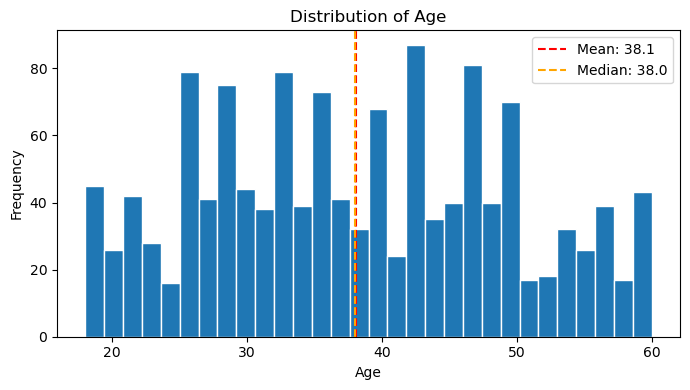

In [5]:
# Distribution of Age
plt.figure(figsize=(7, 4))
plt.hist(df['age'].dropna(), bins=30, edgecolor='white')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
plt.axvline(df['age'].median(), color='orange', linestyle='--', label=f"Median: {df['age'].median():.1f}")
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

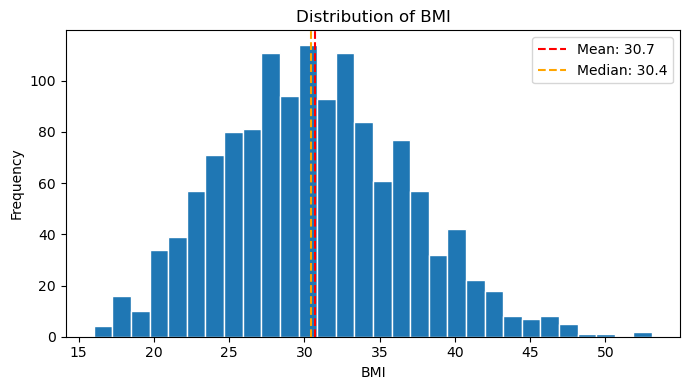

In [6]:
# Distribution of BMI
plt.figure(figsize=(7, 4))
plt.hist(df['bmi'].dropna(), bins=30, edgecolor='white')
plt.axvline(df['bmi'].mean(), color='red', linestyle='--', label=f"Mean: {df['bmi'].mean():.1f}")
plt.axvline(df['bmi'].median(), color='orange', linestyle='--', label=f"Median: {df['bmi'].median():.1f}")
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

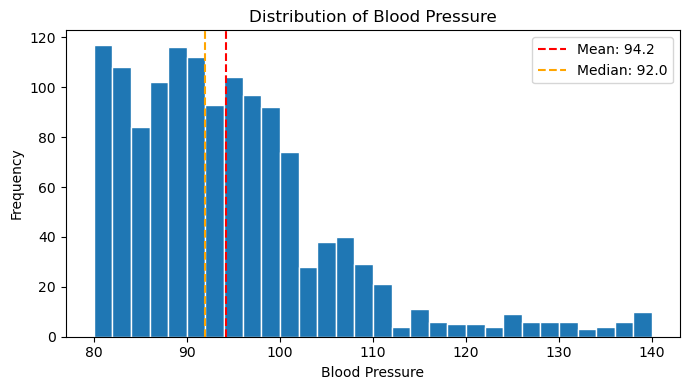

In [7]:
# Distribution of Blood Pressure
plt.figure(figsize=(7, 4))
plt.hist(df['bloodpressure'].dropna(), bins=30, edgecolor='white')
plt.axvline(df['bloodpressure'].mean(), color='red', linestyle='--', label=f"Mean: {df['bloodpressure'].mean():.1f}")
plt.axvline(df['bloodpressure'].median(), color='orange', linestyle='--', label=f"Median: {df['bloodpressure'].median():.1f}")
plt.title('Distribution of Blood Pressure')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

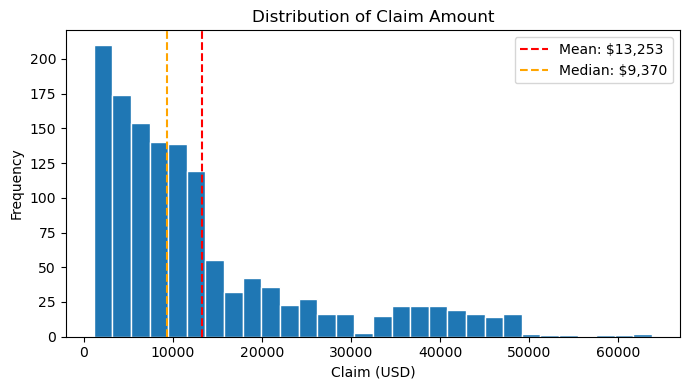

In [8]:
# Distribution of Claim
plt.figure(figsize=(7, 4))
plt.hist(df['claim'].dropna(), bins=30, edgecolor='white')
plt.axvline(df['claim'].mean(), color='red', linestyle='--', label=f"Mean: ${df['claim'].mean():,.0f}")
plt.axvline(df['claim'].median(), color='orange', linestyle='--', label=f"Median: ${df['claim'].median():,.0f}")
plt.title('Distribution of Claim Amount')
plt.xlabel('Claim (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

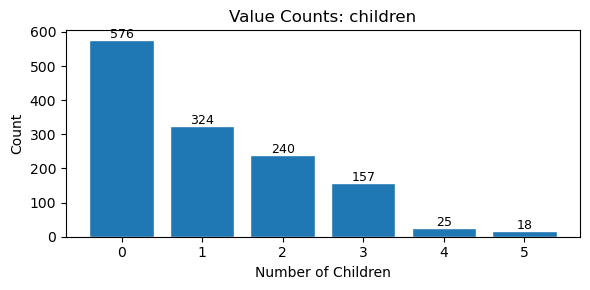

In [9]:
# Children count distribution
counts = df['children'].value_counts().sort_index()

plt.figure(figsize=(6, 3))
plt.bar(counts.index, counts.values, edgecolor='white')
for i, v in zip(counts.index, counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.title('Value Counts: children')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

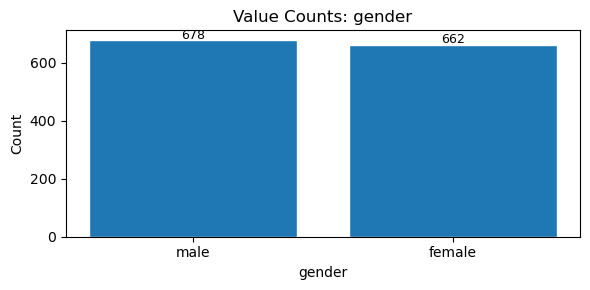

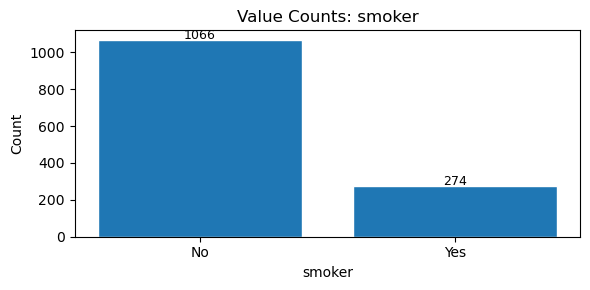

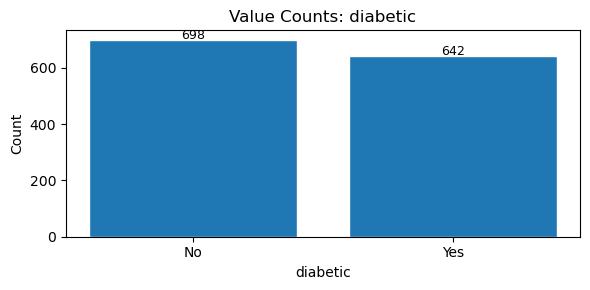

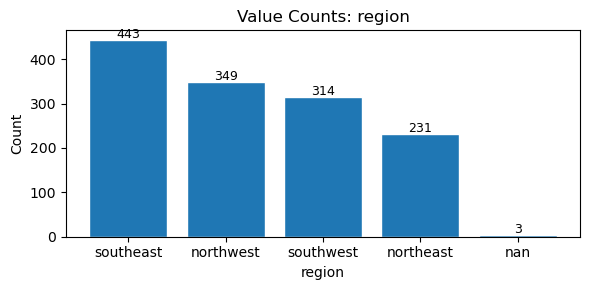

In [10]:
# Categorical feature value counts
cat_cols = ['gender', 'smoker', 'diabetic', 'region']
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    plt.figure(figsize=(6, 3))
    plt.bar(counts.index.astype(str), counts.values, edgecolor='white')
    for i, v in enumerate(counts.values):
        plt.text(i, v + 5, str(v), ha='center', fontsize=9)
    plt.title(f'Value Counts: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

### 3.3 Initial Observations

#### 3.3.1 Patterns
> **Patterns** are consistent group-level differences — which categories tend to have higher or lower claim amounts?

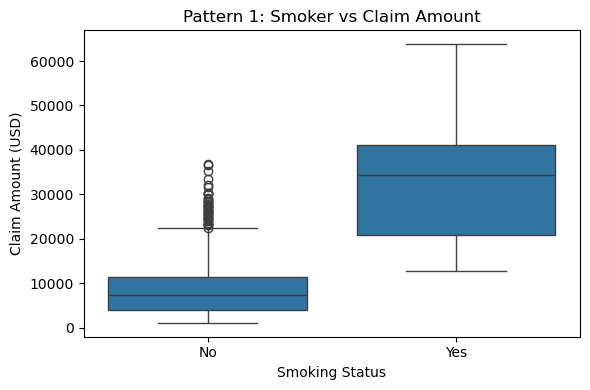

Mean claim by smoker status:
smoker
No      8421.12
Yes    32050.23
Name: claim, dtype: float64


In [11]:
# Pattern 1: Do smokers consistently claim more than non-smokers?
plt.figure(figsize=(6, 4))
sns.boxplot(x='smoker', y='claim', data=df)
plt.title('Pattern 1: Smoker vs Claim Amount')
plt.xlabel('Smoking Status')
plt.ylabel('Claim Amount (USD)')
plt.tight_layout()
plt.show()

print('Mean claim by smoker status:')
print(df.groupby('smoker')['claim'].mean().round(2))

> **Finding:** Smokers have a mean claim of **USD 32,050** vs **USD 8,421** for non-smokers — nearly **4× higher**. Smoking is a strong differentiator in this dataset.

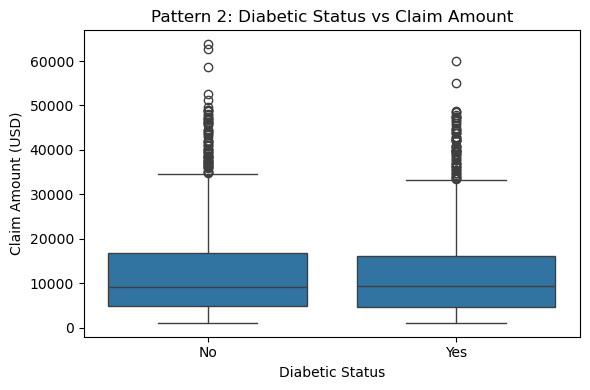

Mean claim by diabetic status:
diabetic
No     13354.03
Yes    13142.62
Name: claim, dtype: float64


In [12]:
# Pattern 2: Does being diabetic lead to higher claims?
plt.figure(figsize=(6, 4))
sns.boxplot(x='diabetic', y='claim', data=df, order=['No', 'Yes'])
plt.title('Pattern 2: Diabetic Status vs Claim Amount')
plt.xlabel('Diabetic Status')
plt.ylabel('Claim Amount (USD)')
plt.tight_layout()
plt.show()

print('Mean claim by diabetic status:')
print(df.groupby('diabetic')['claim'].mean().round(2))

> **Finding:** Diabetic vs non-diabetic mean claims are nearly identical (USD 13,143 vs USD 13,354 — less than 2% difference). Despite visual impression, diabetic status is a weak differentiator on its own.

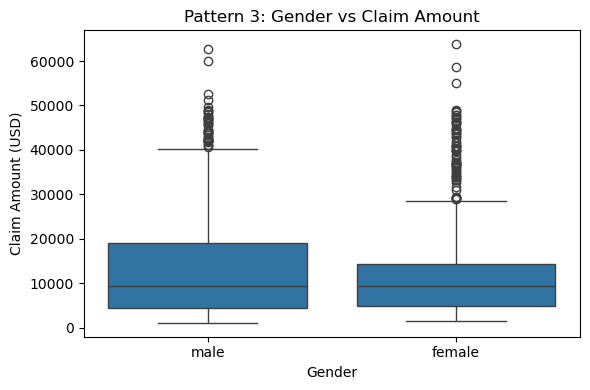

In [13]:
# Pattern 3: Does gender influence claim amount?
plt.figure(figsize=(6, 4))
sns.boxplot(x='gender', y='claim', data=df)
plt.title('Pattern 3: Gender vs Claim Amount')
plt.xlabel('Gender')
plt.ylabel('Claim Amount (USD)')
plt.tight_layout()
plt.show()

> **Finding:** Male and female claim distributions are nearly identical. Gender is not a meaningful differentiator for claim amount in this dataset.

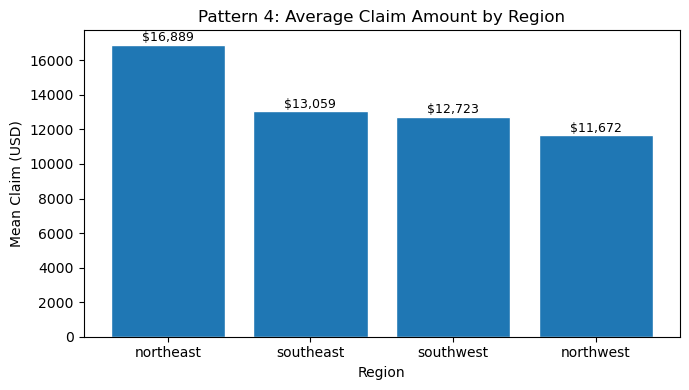

In [14]:
# Pattern 4: Which region has the highest average claim?
region_means = df.groupby('region')['claim'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(region_means.index, region_means.values, edgecolor='white')
for i, v in enumerate(region_means.values):
    plt.text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9)
plt.title('Pattern 4: Average Claim Amount by Region')
plt.xlabel('Region')
plt.ylabel('Mean Claim (USD)')
plt.tight_layout()
plt.show()

In [15]:
print("Smoker rate by region (%):")
print((df.groupby('region')['smoker'].apply(lambda x: (x=='Yes').mean()) * 100).round(1).sort_values(ascending=False))

Smoker rate by region (%):
region
northeast    29.0
southeast    20.5
southwest    18.5
northwest    16.6
Name: smoker, dtype: float64


> **Finding**: Northeast claims the highest mean (USD 16,889) — but **geography isn't the cause**. Its **smoker rate (29.0%)** is also the highest, and the claim ranking mirrors the smoker rate ranking perfectly across all four regions. Region is a proxy for who lives there, not a risk factor on its own.

#### 3.3.2 Trends
> As a numerical value increases, how does claim amount change?

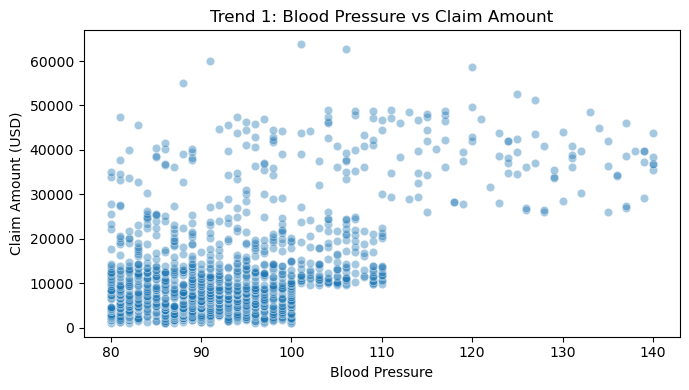

Min claim for BP > 100  : 9549.57
Min claim for BP > 110  : 26018.95
Correlation (Blood Pressure vs Claim): 0.5313


In [16]:
# Trend 1: As blood pressure increases, does claim amount increase?
plt.figure(figsize=(7, 4))
sns.scatterplot(x='bloodpressure', y='claim', data=df, alpha=0.4)
plt.title('Trend 1: Blood Pressure vs Claim Amount')
plt.xlabel('Blood Pressure')
plt.ylabel('Claim Amount (USD)')
plt.tight_layout()
plt.show()
print('Min claim for BP > 100  :', round(df[df['bloodpressure'] > 100]['claim'].min(), 2))
print('Min claim for BP > 110  :', round(df[df['bloodpressure'] > 110]['claim'].min(), 2))


print('Correlation (Blood Pressure vs Claim):', df['bloodpressure'].corr(df['claim']).round(4))

> **Finding:** Blood pressure has the strongest positive correlation with claim (r = 0.53). A clear **risk tier boundary exists**
> 
> **BP > 100**: minimum claim floor rises to approximately **USD 9,550** ;
> **BP > 110**: minimum claim floor jumps again to approximately **USD 26,019**
> 
> Hence, BP acts more like a **classification boundary** than a smooth predictor.

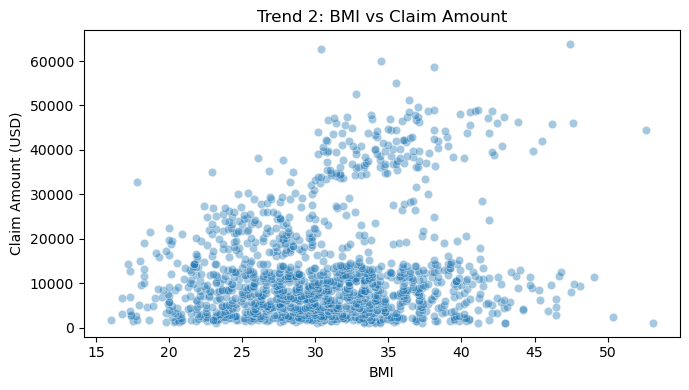

Correlation (BMI vs Claim): 0.1974


In [17]:
# Trend 2: As BMI increases, does claim amount rise?
plt.figure(figsize=(7, 4))
sns.scatterplot(x='bmi', y='claim', data=df, alpha=0.4)
plt.title('Trend 2: BMI vs Claim Amount')
plt.xlabel('BMI')
plt.ylabel('Claim Amount (USD)')
plt.tight_layout()
plt.show()

print('Correlation (BMI vs Claim):', df['bmi'].corr(df['claim']).round(4))

> **Finding:** BMI shows a weak positive correlation with claim (r = 0.20).

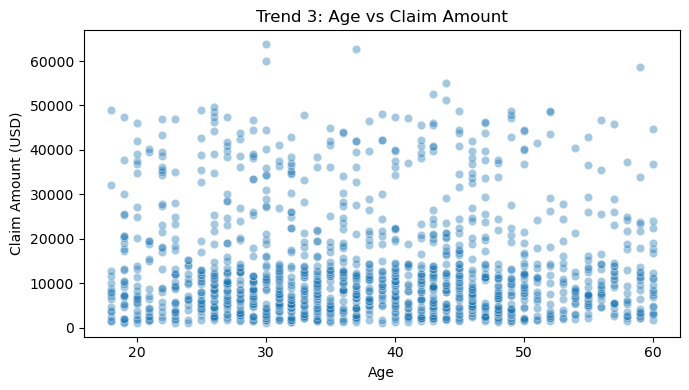

Correlation (Age vs Claim): -0.0279


In [18]:
# Trend 3: As age increases, does claim amount increase?
plt.figure(figsize=(7, 4))
sns.scatterplot(x='age', y='claim', data=df, alpha=0.4)
plt.title('Trend 3: Age vs Claim Amount')
plt.xlabel('Age')
plt.ylabel('Claim Amount (USD)')
plt.tight_layout()
plt.show()

print('Correlation (Age vs Claim):', df['age'].corr(df['claim']).round(4))

> **Finding:** Age shows virtually no linear correlation with claim (r = -0.03). The scatter is flat across all age groups. This is surprising — age is typically a primary insurance risk factor. This sets up Anomaly 2 below.

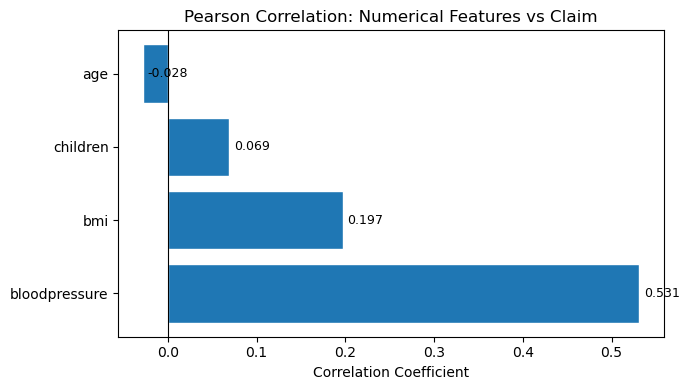

In [19]:
# Correlation summary: all numerical features vs claim
corr_with_claim = df[num_cols].corr()['claim'].drop('claim').sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.barh(corr_with_claim.index, corr_with_claim.values, edgecolor='white')
for i, v in enumerate(corr_with_claim.values):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.title('Pearson Correlation: Numerical Features vs Claim')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

> **Summary:** Blood pressure is the strongest numerical predictor (r = 0.53), followed by BMI (r = 0.20). Children and age contribute negligible linear signal.

#### 3.3.3 Anomalies
> **Anomalies** are unexpected or surprising observations — distributions that deviate from norms, or findings that contradict general assumptions.

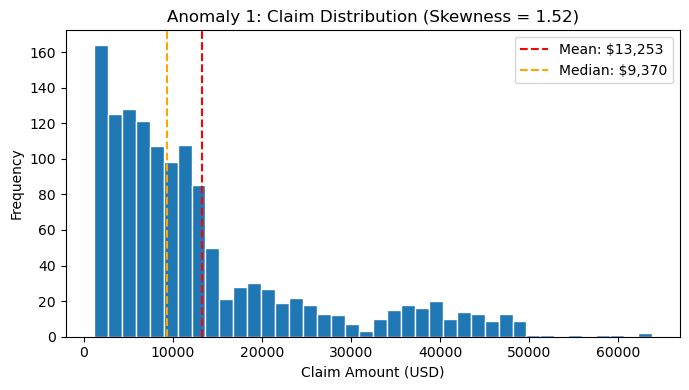

Top 10% claimers (above $34,830):
  Smokers  : 97.8%
  Obese    : 96.3%
  Count    : 134 patients


In [20]:
# Anomaly 1: Why is the claim distribution so heavily right-skewed?
plt.figure(figsize=(7, 4))
plt.hist(df['claim'], bins=40, edgecolor='white')
plt.axvline(df['claim'].mean(), color='red', linestyle='--', label=f"Mean: ${df['claim'].mean():,.0f}")
plt.axvline(df['claim'].median(), color='orange', linestyle='--', label=f"Median: ${df['claim'].median():,.0f}")
plt.title('Anomaly 1: Claim Distribution (Skewness = 1.52)')
plt.xlabel('Claim Amount (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Who are the extreme claimers?
threshold = df['claim'].quantile(0.90)
extreme = df[df['claim'] > threshold]
print(f'Top 10% claimers (above ${threshold:,.0f}):')
print(f'  Smokers  : {(extreme["smoker"]=="Yes").mean()*100:.1f}%')
print(f'  Obese    : {(extreme["bmi"]>=30).mean()*100:.1f}%')
print(f'  Count    : {len(extreme)} patients')

> **Finding:** Claim is strongly right-skewed (skewness = 1.52). The mean (USD 13,253) sits 41% above the median (USD 9,370), indicating a small group of extreme claimers pulling the distribution. Among the top 10% of claimers, **97.8% are smokers and 96.3% are obese** — these are not data errors, but genuine catastrophic medical events driven by compounding risk factors.

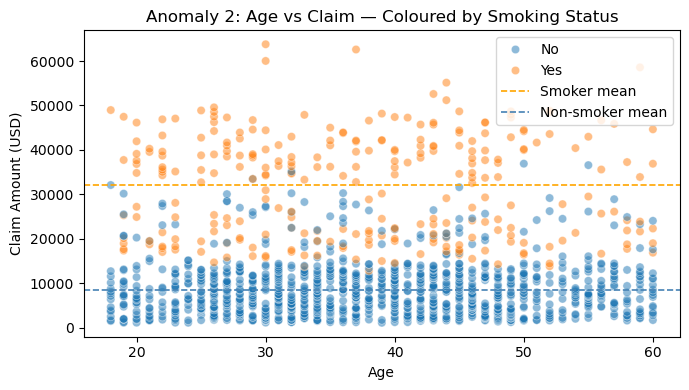

In [21]:
# Anomaly 2: Why does age show almost zero correlation with claim?
plt.figure(figsize=(7, 4))
sns.scatterplot(x='age', y='claim', hue='smoker', data=df, alpha=0.5)
plt.axhline(df[df['smoker']=='Yes']['claim'].mean(), color='orange',
            linestyle='--', linewidth=1.2, label='Smoker mean')
plt.axhline(df[df['smoker']=='No']['claim'].mean(), color='steelblue',
            linestyle='--', linewidth=1.2, label='Non-smoker mean')
plt.title('Anomaly 2: Age vs Claim — Coloured by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Claim Amount (USD)')
plt.legend()
plt.tight_layout()
plt.show()

> **Finding:** Smokers cluster at high claim levels regardless of age, non-smokers cluster low regardless of age.
> 
> This explains the weak age correlation r = -0.03: **age's effect is completely masked by smoking status**, which acts as a dominant override. This is a confounding anomaly — age is not irrelevant, it is simply overshadowed.

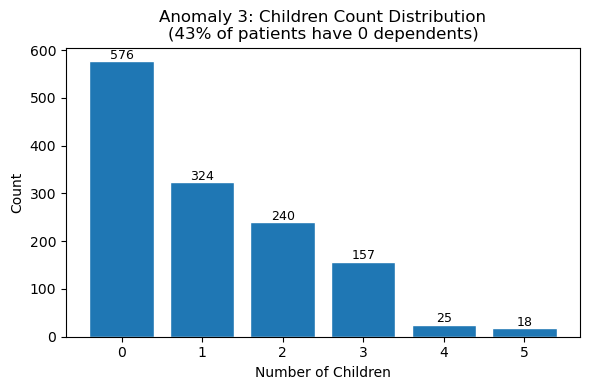

Patients with 0 children: 576 (43.0%)
Patients with 4-5 children: 43 (3.2%)


In [22]:
# Anomaly 3: Why do 43% of patients have zero children?
counts = df['children'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, edgecolor='white')
for i, v in zip(counts.index, counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.title('Anomaly 3: Children Count Distribution\n(43% of patients have 0 dependents)')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

pct_zero = (df['children'] == 0).mean() * 100
print(f'Patients with 0 children: {(df["children"]==0).sum()} ({pct_zero:.1f}%)')
print(f'Patients with 4-5 children: {(df["children"]>=4).sum()} ({(df["children"]>=4).mean()*100:.1f}%)')

> **Finding:** 576 out of 1,340 patients (43%) have zero dependents — a disproportionate spike. Patients with 4–5 children combined represent only 3.2% of records.
>
> Possibly, the dataset primarily samples **individual policyholders** rather than family plans.
>
> Either way, the `children` variable has limited predictive value (r = 0.07) 

---
## Section 4: Data Preprocessing

### 4.1 Handling Missing Values

In [23]:
df_clean = df.copy()

In [24]:
print('Missing values BEFORE treatment:')
print(df_clean.isnull().sum())

Missing values BEFORE treatment:
index            0
PatientID        0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64


In [25]:
# age: impute with median (robust to skew)
age_median = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(age_median)
print(f'age: 5 missing values imputed with median = {age_median}')

# region: impute with mode (most frequent category)
region_mode = df_clean['region'].mode()[0]
df_clean['region'] = df_clean['region'].fillna(region_mode)
print(f'region: 3 missing values imputed with mode = "{region_mode}"')

print()
print('Missing values AFTER treatment:')
print(df_clean.isnull().sum())

age: 5 missing values imputed with median = 38.0
region: 3 missing values imputed with mode = "southeast"

Missing values AFTER treatment:
index            0
PatientID        0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64


**Justification:**
- `age` (5 missing, 0.37%): **Median imputation** chosen over mean because the claim distribution is right-skewed and age could be similarly influenced. Median is robust to outliers. Dropping 5 rows is also acceptable, but imputation retains all 1,340 records.
- `region` (3 missing, 0.22%): **Mode imputation** replaces missing values with the most frequently occurring region (`southeast`), preserving distributional balance without data loss.

### 4.2 Handling Noise and Outliers

In [26]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return outliers, lower, upper

for col in ['bmi', 'bloodpressure', 'claim']:
    out, lo, hi = detect_outliers_iqr(df_clean, col)
    print(f'{col}: {len(out)} outliers | Valid range: [{lo:.2f}, {hi:.2f}]')

bmi: 9 outliers | Valid range: [13.64, 47.34]
bloodpressure: 62 outliers | Valid range: [66.50, 118.50]
claim: 141 outliers | Valid range: [-13107.25, 34431.24]


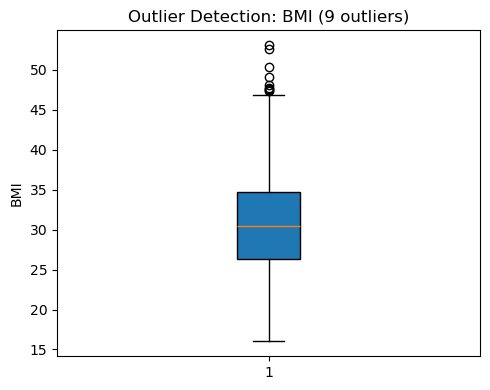

In [27]:
# Boxplot: BMI
plt.figure(figsize=(5, 4))
plt.boxplot(df_clean['bmi'].dropna(), vert=True, patch_artist=True)
plt.title('Outlier Detection: BMI (9 outliers)')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

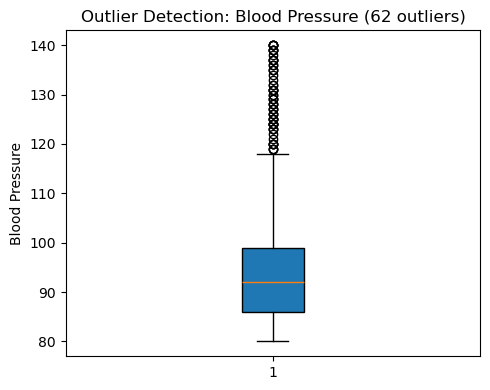

In [28]:
# Boxplot: Blood Pressure
plt.figure(figsize=(5, 4))
plt.boxplot(df_clean['bloodpressure'].dropna(), vert=True, patch_artist=True)
plt.title('Outlier Detection: Blood Pressure (62 outliers)')
plt.ylabel('Blood Pressure')
plt.tight_layout()
plt.show()

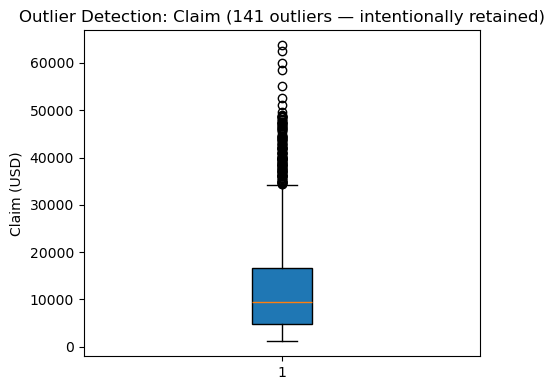

In [29]:
# Boxplot: Claim
plt.figure(figsize=(5, 4))
plt.boxplot(df_clean['claim'].dropna(), vert=True, patch_artist=True)
plt.title('Outlier Detection: Claim (141 outliers — intentionally retained)')
plt.ylabel('Claim (USD)')
plt.tight_layout()
plt.show()

In [30]:
# Treatment: Only Winsorize BMI 
def winsorize_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower=lower, upper=upper)
    print(f'{col} winsorized to [{lower:.2f}, {upper:.2f}]')
    return data

df_clean = winsorize_iqr(df_clean, 'bmi')

bmi winsorized to [13.64, 47.34]


**Justification:**
- **BMI** (9 outliers): Winsorized to IQR fence [13.64, 47.34]. Values beyond this range are extreme. Capping preserves all 1,340 records while reducing distortion.
- **Blood Pressure** (62 outliers): Retained without capping. **High blood pressure (hypertension) (BP>130)** is **clinically meaningful** — it is a genuine health risk marker identified in Section 3.3.2 as a key predictor. Capping it to **upper BP = 118.5** would **remove real signal.**
- **Claim** (141 outliers): Intentionally retained. As confirmed in Anomaly 1, extreme claims are driven by real compounding risk factors (smoker + obese). Removing them would bias any downstream model toward underestimating high-cost patients.

### 4.3 Data Transformation

In [31]:
# Min-Max Normalisation — applied to numerical predictors only
# claim (target variable) is intentionally excluded from scaling
scaler = MinMaxScaler()
scale_cols = ['age', 'bmi', 'bloodpressure', 'children']
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])
print('Min-Max scaling applied to:', scale_cols)

Min-Max scaling applied to: ['age', 'bmi', 'bloodpressure', 'children']


In [32]:
# Binary encoding for Yes/No and male/female columns
binary_map = {'Yes': 1, 'No': 0, 'male': 1, 'female': 0}
for col in ['gender', 'diabetic', 'smoker']:
    df_clean[col] = df_clean[col].map(binary_map)
    print(f'{col} → binary encoded (0/1)')

gender → binary encoded (0/1)
diabetic → binary encoded (0/1)
smoker → binary encoded (0/1)


In [33]:
# One-Hot Encoding for region (4 nominal categories, no inherent order)
region_dummies = pd.get_dummies(df_clean['region'], prefix='region', dtype=int)
df_clean = df_clean.drop(columns=['region'])
df_clean = pd.concat([df_clean, region_dummies], axis=1)
print('region → one-hot encoded into:', list(region_dummies.columns))

region → one-hot encoded into: ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [34]:
df_clean.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,region_northeast,region_northwest,region_southeast,region_southwest
0,0,1,0.500000,1,0.229757,0.183333,1,0.0,0,1121.87,0,0,1,0
1,1,2,0.142857,1,0.449940,0.116667,0,0.0,0,1131.51,0,0,1,0
2,2,3,0.476190,1,0.552054,0.033333,1,0.0,0,1135.94,0,0,1,0
3,3,4,0.476190,1,0.564819,0.000000,0,0.0,0,1136.40,0,1,0,0
4,4,5,0.476190,1,0.577583,0.333333,0,0.0,0,1137.01,0,1,0,0


**Justification:**
- **Min-Max Normalisation** scales `age`, `bmi`, `bloodpressure`, `children` to [0, 1]. This ensures no single feature dominates due to its magnitude — critical for distance-based and gradient-based algorithms. `claim` is excluded as it is the target variable.
- **Binary encoding** is used for `gender`, `diabetic`, and `smoker` — each has exactly two categories with clear binary semantics (Yes/No, male/female).
- **One-Hot Encoding** is used for `region` because it has 4 nominal categories with no inherent order. 

### 4.4 Data Cleaning

In [35]:
# Check for duplicates
dup_count = df_clean.duplicated().sum()
print(f'Duplicate records: {dup_count}')

# Drop identifier columns — no predictive value
cols_to_drop = ['index', 'PatientID']
df_final = df_clean.drop(columns=cols_to_drop)

print(f'Dropped columns: {cols_to_drop}')
print(f'Final dataset shape: {df_final.shape}')
print('\nFinal columns:')
print(df_final.columns.tolist())

Duplicate records: 0
Dropped columns: ['index', 'PatientID']
Final dataset shape: (1340, 12)

Final columns:
['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker', 'claim', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [36]:
# Final data quality summary
print(f'Records       : {df_final.shape[0]}')
print(f'Features      : {df_final.shape[1]}')
print(f'Missing values: {df_final.isnull().sum().sum()}')
print(f'Duplicates    : {df_final.duplicated().sum()}')
print()

Records       : 1340
Features      : 12
Missing values: 0
Duplicates    : 0



In [37]:
df_final.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,region_northeast,region_northwest,region_southeast,region_southwest
0,0.500000,1,0.229757,0.183333,1,0.0,0,1121.87,0,0,1,0
1,0.142857,1,0.449940,0.116667,0,0.0,0,1131.51,0,0,1,0
2,0.476190,1,0.552054,0.033333,1,0.0,0,1135.94,0,0,1,0
3,0.476190,1,0.564819,0.000000,0,0.0,0,1136.40,0,1,0,0
4,0.476190,1,0.577583,0.333333,0,0.0,0,1137.01,0,1,0,0


In [38]:
df_final.to_csv('insurance_data_preprocessed.csv', index=False)
print('Preprocessed dataset saved to: insurance_data_preprocessed.csv')

Preprocessed dataset saved to: insurance_data_preprocessed.csv


**Justification:**
- **No duplicates** were found — no rows removed.
- `index` and `PatientID` were dropped as row identifiers with no predictive value. Retaining them risks model leakage in future phases.
- All original categorical columns were replaced by their encoded counterparts in Section 4.3; no redundant columns remain.
- Cleaning was confirmed as the final step after all transformations to ensure a fully processed export.